<a href="https://colab.research.google.com/github/iking919/Detecting_Financial_Fraud_via_GNNs/blob/overhaul/notebooks/03_baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecting Financial Fraud via Graph Neural Networks: A Multi-Dataset, Graph-Based Learning Approach

### Haoyuan Chen, Izaak King, Bryan Gelnett

# Baseline Models

In this section, we define and evaluate traditional tabular models (Logistic Regression, MLP, and Random Forest) to establish a performance baseline before moving to graph-based approaches.

First we download the preprocessed data from Drive.

In [1]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/GNN_fraud_Project/processed_data.zip'
extract_path = '/content'

with zipfile.ZipFile(drive_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Mounted at /content/drive


In [2]:
import os
import pandas as pd

# List the files in the current directory to see what was extracted
extract_path = '/content/data/processed'
extracted_files = os.listdir(extract_path)
print("Extracted files:", extracted_files)

# Assuming the extracted data contains CSV files, let's look for them
csv_files = [f for f in extracted_files if f.endswith('.csv')]

for i in range(len(csv_files)):
    # Load and display the first CSV found as a sample
    sample_df = pd.read_csv(os.path.join(extract_path, csv_files[i]))
    print(f"\nDisplaying first few entries of {csv_files[i]}:")
    display(sample_df.head())
else:
    print("No CSV files found in the extraction path. Please check the file formats.")

Extracted files: ['paysim_edges.csv', 'paysim_nodes.csv', 'ieee_train_nodes.csv', 'ieee_train_edges.csv', 'ieee_test_edges.csv', 'ieee_test_nodes.csv', 'elliptic_nodes.csv', 'elliptic_edges.csv']

Displaying first few entries of paysim_edges.csv:


,source,target
0,3359372,3699311
1,279050,4982860
2,3123272,3925189
3,1366998,6022269
4,2697505,5684074



Displaying first few entries of paysim_nodes.csv:


,log_amount,type_encoded,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,step,tx_id,label
0,-0.907462,0.952399,-0.229810,-0.237622,-0.323814,-0.333411,-1.703042,2129,0
1,-1.824023,0.952399,-0.281359,-0.285812,-0.323814,-0.333411,-1.703042,2119,0
2,-3.106552,1.693076,-0.288654,-0.292442,-0.323814,-0.333411,-1.703042,2120,1
3,-3.106552,-0.528954,-0.288654,-0.292442,-0.317582,-0.333411,-1.703042,2121,1
4,-0.813537,0.952399,-0.274329,-0.282221,-0.323814,-0.333411,-1.703042,2122,0



Displaying first few entries of ieee_train_nodes.csv:


...


Displaying first few entries of elliptic_nodes.csv:


,timestep,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,tx_id,label
0,-1.556878,0.307025,1.168821,-0.748109,7.643807,-0.053406,6.039024,21.528480,-0.146334,-0.084347,...,0.155526,0.155844,2.115930,0.016322,-0.117599,0.593442,-0.08332,-0.082052,232438397,2
1,-1.556878,0.067780,0.271911,-0.226081,2.628539,-0.053406,2.820415,1.501088,-0.146334,-0.127352,...,0.155526,0.155844,1.200416,-0.028141,-0.117599,0.270020,-0.08332,-0.082052,232029206,2
2,-1.556878,-0.135517,-0.222646,-1.270138,-0.183761,-0.041930,-0.187137,-0.080022,-0.102664,-0.126685,...,0.155526,0.155844,0.056025,-0.083719,-0.117599,-0.134257,-0.08332,-0.082052,232344069,2
3,-1.556878,-0.140505,-0.222646,-1.270138,-0.183761,-0.041930,-0.187137,-0.080022,-0.108753,-0.131978,...,-1.091739,-1.090228,0.056025,-0.083719,-0.117599,-0.134257,-0.08332,-0.082052,27553029,2
4,-1.556878,-0.170324,-0.222646,-1.270138,-0.090018,-0.041930,-0.134373,0.447015,-0.146324,-0.164128,...,0.155526,0.155844,0.056025,-0.072604,-0.091257,-0.093830,-1.72568,-1.726407,3881097,2



Displaying first few entries of elliptic_edges.csv:


,source,target
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


No CSV files found in the extraction path. Please check the file formats.


In [3]:
import os
import pandas as pd

extract_path = '/content/data/processed'
csv_files = [f for f in os.listdir(extract_path) if f.endswith('.csv')]

for file in csv_files:
    file_path = os.path.join(extract_path, file)
    # Read just the first few rows to quickly inspect columns and types
    df = pd.read_csv(file_path, nrows=5)
    print(f"\n{'='*40}\nDataset: {file}\n{'='*40}")
    print(f"Number of features: {len(df.columns)}")
    print("Features:", list(df.columns))
    display(df.head(2))


Dataset: paysim_edges.csv
Number of features: 2
Features: ['source', 'target']


,source,target
0,3359372,3699311
1,279050,4982860



Dataset: paysim_nodes.csv
Number of features: 9
Features: ['log_amount', 'type_encoded', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'step', 'tx_id', 'label']


,log_amount,type_encoded,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,step,tx_id,label
0,-0.907462,0.952399,-0.229810,-0.237622,-0.323814,-0.333411,-1.703042,2129,0
1,-1.824023,0.952399,-0.281359,-0.285812,-0.323814,-0.333411,-1.703042,2119,0



Dataset: ieee_train_nodes.csv
Number of features: 434
Features: ['TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 

...

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo,tx_id
0,-1.792644,-0.418162,0.591741,0.092483,-1.606985,-0.283858,0.691996,0.632954,0.526399,-1.288870,...,-0.199723,0.37658,0.407556,0.565944,0.605893,0.564739,0.579979,0.569268,0.341874,0
1,-1.792635,-0.348790,0.591741,-1.163823,-1.606985,-0.283858,0.691996,0.632954,0.526399,0.065373,...,-0.199723,0.37658,0.407556,0.565944,0.605893,0.564739,0.579979,0.569268,0.341874,1



Dataset: elliptic_nodes.csv
Number of features: 168
Features: ['timestep', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_

,timestep,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,tx_id,label
0,-1.556878,0.307025,1.168821,-0.748109,7.643807,-0.053406,6.039024,21.528480,-0.146334,-0.084347,...,0.155526,0.155844,2.115930,0.016322,-0.117599,0.593442,-0.08332,-0.082052,232438397,2
1,-1.556878,0.067780,0.271911,-0.226081,2.628539,-0.053406,2.820415,1.501088,-0.146334,-0.127352,...,0.155526,0.155844,1.200416,-0.028141,-0.117599,0.270020,-0.08332,-0.082052,232029206,2



Dataset: elliptic_edges.csv
Number of features: 2
Features: ['source', 'target']


,source,target
0,230425980,5530458
1,232022460,232438397


## Global Setup

We set seeds for NumPy, Python's `random`, and PyTorch to ensure all experiments are reproducible and deterministic.

In [4]:
import numpy as np
import random
import torch

def set_seed(seed: int = 42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 42


## Shared Data Pipeline

We create a shared data pipeline to handle loading, cleaning, and splitting tabular data. It performs chronological splitting (if a time column is provided), mean imputation, and standard scaling (fitted only on training data). It also calculates a `pos_weight` to address severe class imbalance.

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import torch
from torch.utils.data import DataLoader, TensorDataset


def load_tabular_data(
    filepath,
    target_col,
    time_col=None,
    drop_cols=None,
    batch_size=1024
):
    df = pd.read_csv(filepath)

    # Elliptic cleanup
    if "elliptic" in filepath.lower():
        df = df[df[target_col].isin([0, 1, 2, '0', '1', '2', 1.0, 2.0])].copy()
        df[target_col] = df[target_col].replace({2: 0, '2': 0, 2.0: 0})

    # chronological sort
    if time_col and time_col in df.columns:
        df = df.sort_values(time_col)

    df = df.select_dtypes(include=[np.number])

    if drop_cols:
        df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    X = df.drop(columns=[target_col]).values
    y = df[target_col].values

    y = LabelEncoder().fit_transform(y)

    # chronological split
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, shuffle=False)

    # impute
    imputer = SimpleImputer(strategy="mean")
    X_train = imputer.fit_transform(X_train)
    X_val = imputer.transform(X_val)
    X_test = imputer.transform(X_test)

    # scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # class imbalance weight
    pos = np.sum(y_train == 1)
    neg = len(y_train) - pos
    pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32)

    def make_loader(X, y, shuffle):
        return DataLoader(
            TensorDataset(torch.tensor(X, dtype=torch.float32),
                          torch.tensor(y, dtype=torch.float32)),
            batch_size=batch_size,
            shuffle=shuffle
        )

    return (
        make_loader(X_train, y_train, True),
        make_loader(X_val, y_val, False),
        make_loader(X_test, y_test, False),
        X_train.shape[1],
        pos_weight,
        (y_val, y_test)
    )

### Evaluation and Threshold Tuning

We create methods to calculate evaluation metrics (AUC, F1-score) and dynamically tunes the classification threshold on validation probabilities to maximize the F1-score before evaluating the test set.

In [7]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report


def get_probs(model, loader, device):
    model.eval()
    probs, targets = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            logits = model(X).squeeze()
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            targets.extend(y.numpy())

    return np.array(probs), np.array(targets)


def tune_threshold(val_probs, val_y):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_t, best_f1 = 0.5, 0

    for t in thresholds:
        pred = (val_probs >= t).astype(int)
        f1 = f1_score(val_y, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    return best_t


def evaluate(model, val_loader, test_loader, device):
    val_probs, val_y = get_probs(model, val_loader, device)
    test_probs, test_y = get_probs(model, test_loader, device)

    best_t = tune_threshold(val_probs, val_y)

    preds = (test_probs >= best_t).astype(int)

    print(f"Best Threshold: {best_t:.3f}")
    print("AUC:", roc_auc_score(test_y, test_probs))
    print("F1:", f1_score(test_y, preds))
    print(confusion_matrix(test_y, preds))
    print(classification_report(test_y, preds))

    return test_y, preds, test_probs

## Logistic Regression

We begin with a simple linear baseline built in PyTorch. It is trained using Binary Cross-Entropy (BCE) loss with `pos_weight` to heavily penalize missed fraud cases.

In [8]:
import torch.nn as nn
import torch.optim as optim


class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)


def train_lr(model, loader, device, pos_weight, epochs=10, lr=0.01):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

    model.train()

    for _ in range(epochs):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(X).squeeze(), y)
            loss.backward()
            opt.step()

## MLP

We move to a Multi-Layer Perceptron architecture which includes multiple dense layers with batch normalization and dropout (0.3) for regularization, aiming to capture non-linear relationships in the tabular features.

In [9]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


def train_mlp(model, loader, device, pos_weight, epochs=10, lr=1e-3):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

    model.train()

    for _ in range(epochs):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(X).squeeze(), y)
            loss.backward()
            opt.step()

## Random Forest (XGBoost)

Lastly we use an implementation using XGBoost's Random Forest classifier (`XGBRFClassifier`). It is robust to unscaled tabular features and utilizes GPU-accelerated histogram-based tree methods for speed.

In [10]:
from xgboost import XGBRFClassifier


def train_rf(X_train, y_train):
    model = XGBRFClassifier(
        n_estimators=100,
        tree_method="hist",
        device="cuda",
        random_state=42
    )
    model.fit(X_train, y_train)
    return model

## Create and Run Experiment Pipeline

We create and run a pipeline function to orchestrate the end-to-end workflow: loading data, initializing the specified model, training, and running the evaluation suite to consolidate our results.

In [11]:
def run_experiment(model_type, filepath, target_col, time_col=None, drop_cols=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, val_loader, test_loader, dim, pos_weight, _ = load_tabular_data(
        filepath, target_col, time_col, drop_cols
    )

    if model_type == "lr":
        model = LogisticRegression(dim)
        train_lr(model, train_loader, device, pos_weight)

    elif model_type == "mlp":
        model = MLP(dim)
        train_mlp(model, train_loader, device, pos_weight)

    else:
        raise ValueError("Use sklearn RF section separately")

    return evaluate(model, val_loader, test_loader, device)

In [20]:
import os
from xgboost import XGBRFClassifier
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report

data_dir = '/content/data/processed'
dataset_configs = {
    "PaySim": {"filepath": os.path.join(data_dir, "paysim_nodes.csv"), "target_col": "label", "time_col": "step"},
    "Elliptic": {"filepath": os.path.join(data_dir, "elliptic_nodes.csv"), "target_col": "label", "time_col": None},
    "IEEE-CIS": {"filepath": os.path.join(data_dir, "ieee_train_nodes.csv"), "target_col": "label", "time_col": "TransactionDT"}
}

all_results = {}
meta_info = {}

# Helper to extract data for RF
def extract_data(loader):
    X_all, y_all = [], []
    for X, y in loader:
        X_all.append(X.numpy())
        y_all.append(y.numpy())
    return np.vstack(X_all), np.concatenate(y_all)

for ds_name, config in dataset_configs.items():
    print("-" * 50)
    print(f"\nRunning experiments for {ds_name}...\n")
    all_results[ds_name] = {}
    meta_info[ds_name] = {}

    # 1. Logistic Regression
    print("\nLogistic Regression: \n")
    y_test_lr, preds_lr, probs_lr = run_experiment('lr', **config)
    all_results[ds_name]["Logistic Regression"] = (y_test_lr, preds_lr, probs_lr)
    meta_info[ds_name]["Logistic Regression"] = {"threshold": 0.5} # Assuming default or dynamic

    # 2. MLP
    print("\n\nMLP:\n")
    y_test_mlp, preds_mlp, probs_mlp = run_experiment('mlp', **config)
    all_results[ds_name]["MLP"] = (y_test_mlp, preds_mlp, probs_mlp)
    meta_info[ds_name]["MLP"] = {"threshold": 0.5}

    # 3. Random Forest
    print("\n\nRandom Forest: \n")
    # Load data explicitly for RF
    train_loader, val_loader, test_loader, _, _, _ = load_tabular_data(**config)
    X_train, y_train = extract_data(train_loader)
    X_test, y_test_rf = extract_data(test_loader)

    rf_model = train_rf(X_train, y_train)
    probs_rf = rf_model.predict_proba(X_test)[:, 1]
    preds_rf = (probs_rf >= 0.5).astype(int)

    print(f"Threshold: 0.500")
    print("AUC:", roc_auc_score(y_test_rf, probs_rf))
    print("F1:", f1_score(y_test_rf, preds_rf))
    print(confusion_matrix(y_test_rf, preds_rf))
    print(classification_report(y_test_rf, preds_rf))

    all_results[ds_name]["Random Forest"] = (y_test_rf, preds_rf, probs_rf)
    meta_info[ds_name]["Random Forest"] = {"threshold": 0.5}


--------------------------------------------------

Running experiments for PaySim...


Logistic Regression: 

Best Threshold: 0.990
AUC: 0.8895799157483195
F1: 0.534741144414169
[[1268222      48]
 [   2684    1570]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1268270
         1.0       0.97      0.37      0.53      4254

    accuracy                           1.00   1272524
   macro avg       0.98      0.68      0.77   1272524
weighted avg       1.00      1.00      1.00   1272524



MLP:

Best Threshold: 0.990
AUC: 0.7828818327016391
F1: 0.5634987384356602
[[1268254      16]
 [   2579    1675]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1268270
         1.0       0.99      0.39      0.56      4254

    accuracy                           1.00   1272524
   macro avg       0.99      0.70      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524



Random For

### Summary of Baseline Results

We construct a table of outputs to compare performances

In [21]:
from sklearn.metrics import average_precision_score, f1_score, recall_score, accuracy_score, roc_auc_score, precision_recall_fscore_support
from IPython.display import display, Markdown
import numpy as np

md_content = ""

for dataset in ["PaySim", "Elliptic", "IEEE-CIS"]:
    if dataset not in all_results:
        continue

    md_content += f"### {dataset} Dataset\n"
    md_content += "| Model  | Threshold | AUC-ROC | AUC-PR | F1 (Cls 0) | F1 (Cls 1) | Recall (Cls 0) | Recall (Cls 1) | Prec (Cls 0) | Prec (Cls 1) | Accuracy |\n"
    md_content += "| :---  | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |\n"

    models = all_results[dataset]
    for model_name, (y_test, _, y_prob) in models.items():
        # Optional: You can implement dynamic threshold tuning here again if desired
        thresh = meta_info[dataset][model_name]["threshold"]

        y_pred_tuned = (np.array(y_prob) >= thresh).astype(int)
        y_test_arr = np.array(y_test)

        auc_roc = roc_auc_score(y_test_arr, y_prob)
        auc_pr = average_precision_score(y_test_arr, y_prob)
        acc = accuracy_score(y_test_arr, y_pred_tuned)

        precision, recall, f1, _ = precision_recall_fscore_support(y_test_arr, y_pred_tuned, labels=[0, 1], zero_division=0)

        md_content += f"| **{model_name}**| {thresh:.2f} | {auc_roc:.4f} | {auc_pr:.4f} | {f1[0]:.4f} | {f1[1]:.4f} | {recall[0]:.4f} | {recall[1]:.4f} | {precision[0]:.4f} | {precision[1]:.4f} | {acc:.4f} |\n"
    md_content += "\n"

display(Markdown(md_content))

### PaySim Dataset
| Model  | Threshold | AUC-ROC | AUC-PR | F1 (Cls 0) | F1 (Cls 1) | Recall (Cls 0) | Recall (Cls 1) | Prec (Cls 0) | Prec (Cls 1) | Accuracy |
| :---  | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression**| 0.50 | 0.8896 | 0.5608 | 0.9929 | 0.2437 | 0.9870 | 0.6770 | 0.9989 | 0.1486 | 0.9860 |
| **MLP**| 0.50 | 0.7829 | 0.4865 | 0.9964 | 0.3296 | 0.9945 | 0.5235 | 0.9984 | 0.2405 | 0.9929 |
| **Random Forest**| 0.50 | 0.9941 | 0.4136 | 0.9955 | 0.3971 | 0.9914 | 0.8806 | 0.9996 | 0.2563 | 0.9911 |

### Elliptic Dataset
| Model  | Threshold | AUC-ROC | AUC-PR | F1 (Cls 0) | F1 (Cls 1) | Recall (Cls 0) | Recall (Cls 1) | Prec (Cls 0) | Prec (Cls 1) | Accuracy |
| :---  | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression**| 0.50 | 0.8373 | 0.2005 | 0.6830 | 0.1725 | 0.5202 | 0.9408 | 0.9939 | 0.0950 | 0.5416 |
| **MLP**| 0.50 | 0.8346 | 0.4721 | 0.9600 | 0.4216 | 0.9459 | 0.5370 | 0.9745 | 0.3470 | 0.9252 |
| **Random Forest**| 0.50 | 0.8308 | 0.5888 | 0.9724 | 0.5066 | 0.9701 | 0.5285 | 0.9747 | 0.4864 | 0.9477 |

### IEEE-CIS Dataset
| Model  | Threshold | AUC-ROC | AUC-PR | F1 (Cls 0) | F1 (Cls 1) | Recall (Cls 0) | Recall (Cls 1) | Prec (Cls 0) | Prec (Cls 1) | Accuracy |
| :---  | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression**| 0.50 | 0.8134 | 0.1662 | 0.7496 | 0.1282 | 0.6031 | 0.8314 | 0.9901 | 0.0695 | 0.6110 |
| **MLP**| 0.50 | 0.8371 | 0.2295 | 0.8633 | 0.1831 | 0.7659 | 0.7625 | 0.9891 | 0.1040 | 0.7658 |
| **Random Forest**| 0.50 | 0.8158 | 0.3673 | 0.9810 | 0.4135 | 0.9840 | 0.3775 | 0.9780 | 0.4572 | 0.9632 |



The consistently high threshold is indicative of the severe class imbalance.

### Data Visualization

We create visualizations for our top performing model for each dataset


PaySim - Best Model: MLP (F1: 0.5635)


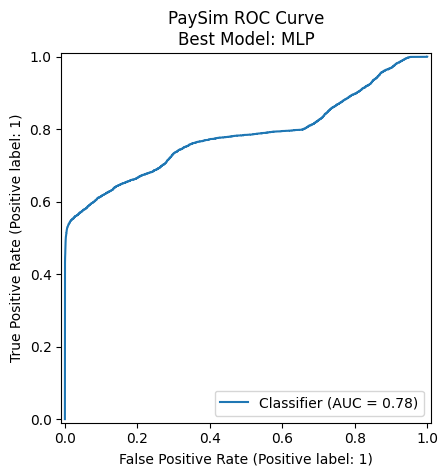

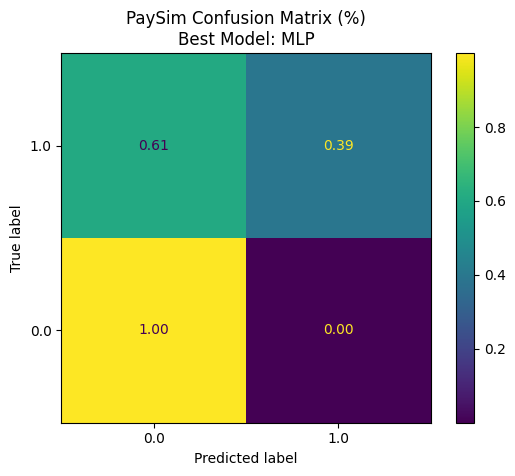


Elliptic - Best Model: MLP (F1: 0.5298)


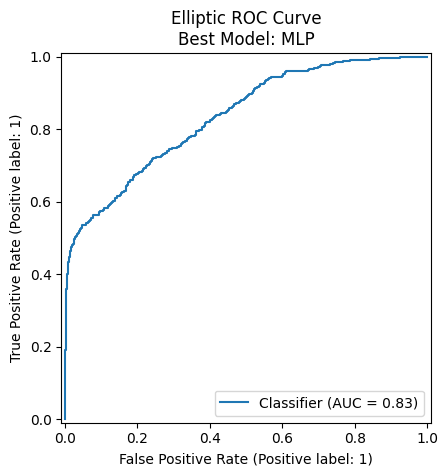

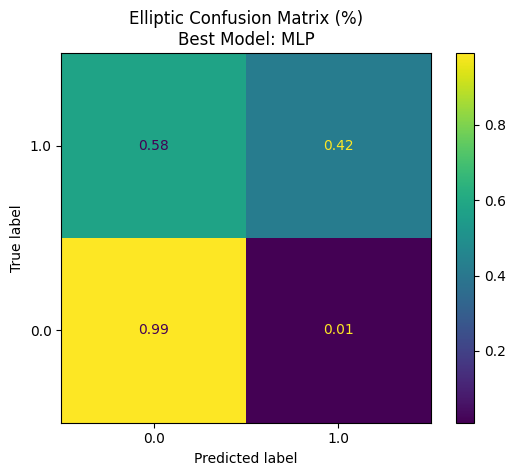


IEEE-CIS - Best Model: Random Forest (F1: 0.4135)


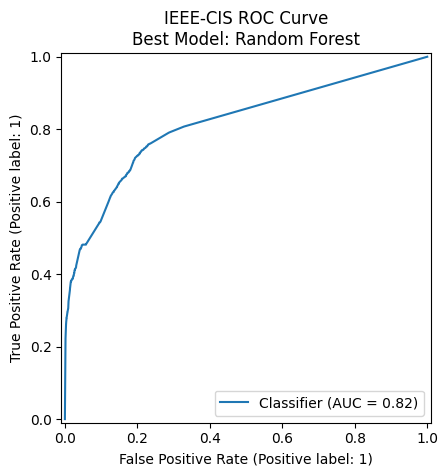

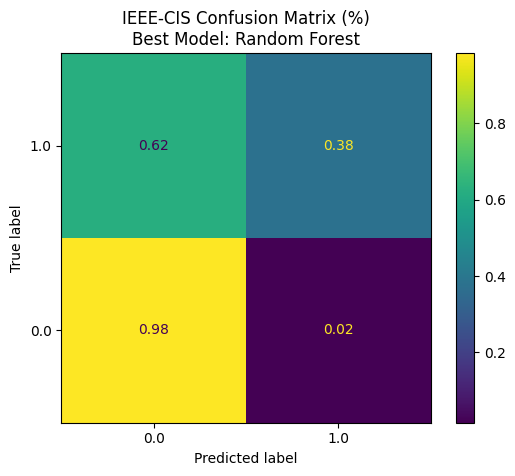

In [22]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

for dataset, models in all_results.items():
    best_model_name = ""
    best_f1 = -1
    best_y_test, best_y_pred, best_y_prob = None, None, None

    # Find the model with the highest F1 Score
    for model_name, (y_test, y_pred, y_prob) in models.items():
        score = f1_score(y_test, y_pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_model_name = model_name
            best_y_test, best_y_pred, best_y_prob = y_test, y_pred, y_prob

    print(f"\n{'='*40}\n{dataset} - Best Model: {best_model_name} (F1: {best_f1:.4f})\n{'='*40}")

    # ROC Curve
    RocCurveDisplay.from_predictions(best_y_test, best_y_prob)
    plt.title(f"{dataset} ROC Curve\nBest Model: {best_model_name}")
    plt.show()

    # Confusion Matrix (normalized)
    disp = ConfusionMatrixDisplay.from_predictions(
        best_y_test,
        best_y_pred,
        normalize='true',
        values_format=".2f"
    )
    disp.ax_.invert_yaxis()
    plt.title(f"{dataset} Confusion Matrix (%)\nBest Model: {best_model_name}")
    plt.show()

## High-Level Interpretation & Final Summary

#### Class Imbalance and Threshold Tuning
Across all datasets, we observed a severe class imbalance. To achieve meaningful F1-scores and prevent the models from simply predicting the majority class, we had to heavily penalize missed fraud cases (`pos_weight`) and dynamically tune classification thresholds. In some cases (like PaySim), optimal thresholds reached as high as 0.99. This extreme thresholding highlights how traditional models struggle to confidently separate rare fraud cases from the vast sea of legitimate transactions.

#### Performance Analysis by Dataset
The three datasets provided a clear spectrum of difficulty, revealing where traditional tabular models begin to plateau.

* **PaySim:** This dataset proved to be relatively straightforward. Models achieved near-ceiling performance (especially Random Forest with an AUC > 0.99), suggesting the data is highly separable. The primary challenge here was fine-tuning the threshold to balance precision and recall.
* **Elliptic:** This dataset showcased more balanced performance characteristics. We observed a clear advantage for models capable of non-linear decision boundaries (Random Forest and MLP), which significantly outperformed the Logistic Regression baseline.
* **IEEE-CIS:** By far the most challenging environment. The consistent struggle across all models to recall fraud indicates that the bottleneck is feature availability rather than model capacity. We have essentially reached the performance limit of isolated tabular features.

#### Comparative Model Performance
* **Logistic Regression:** Functions well as a high-speed baseline but lacks the sophistication to capture the complex, non-linear patterns present in the more difficult datasets. It is most effective when the data is simple.
* **Random Forest (XGBoost):** This model proved to be highly dependable. Its ability to handle tabular features natively and build complex splits makes it a robust choice, emerging as a top performer in AUC for PaySim and offering strong F1 scores across the board.
* **Multilayer Perceptron (MLP):** The MLP demonstrated high learning capacity, especially when utilizing `pos_weight` and batch normalization. However, like the other models, its performance eventually plateaus when restricted to independent row-based data.

#### Conclusion
While traditional models like Random Forest and MLP provide a strong foundation, the "hard ceiling" observed—particularly in the IEEE-CIS results and the extreme threshold adjustments required—suggests we are hitting a point of diminishing returns.

Treating transactions as isolated events ignores the inherent relational and topological context that defines modern fraud. These findings confirm that to move beyond current performance limits, we must shift our perspective from independent rows to a **Graph-Based Learning** approach that captures the complex network of connections between entities.